# Q7

## A, What does the code do?

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25
   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       4
1         8.3014     37.86    -122.22       4
2         7.2574     37.85    -122.24       4
3         5.6431     37.85    -122.25       4
4         3.8462     37.85    -122.25       5


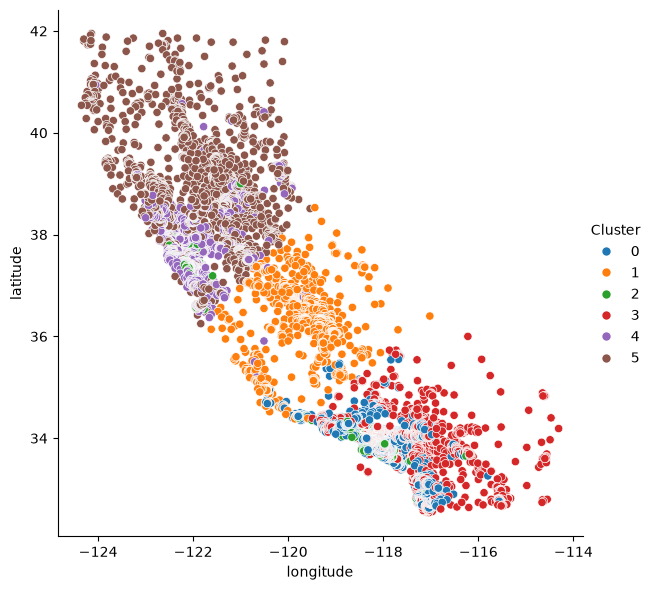

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

# Read the dataset containing housing data
df = pd.read_csv("Datasets/housing.csv")

# Extract relevant features: income and geographical coordinates
X = df.loc[:, ["median_income", "latitude", "longitude"]]
print(X.head())

# Initialize KMeans algorithm to segment data into 6 clusters
kmeans = KMeans(n_clusters=6)

# Fit the model and assign each data point to a cluster
X["Cluster"] = kmeans.fit_predict(X)

# Convert cluster numbers to categorical type for proper plotting
X["Cluster"] = X["Cluster"].astype("category")
print(X.head())

# Create a scatter plot representing geographical coordinates colored by cluster
sns.relplot(
    x="longitude", y="latitude", hue="Cluster", data=X, height=6
)

*** Answer ***

The code performs a clustring av real estate data based on geographical location,
income and then visualises it by maping the points to their geographical location.

The end results is a pretty good overview of the Californian housing market.

### B, We've got six clusters in the code. In real life, you could investigate each seperate cluster inddividually to see which prefrences they have. Such as how do they prefer being contacted, what type of houses they like and such. If you were leading an investigation regarding this, which information would you want to have regarding each cluster and how would you have designed the market research?

***Answer***

I'd want the demograpichal profile based on age, household size, what type of employement they have
and also if they're a family with kids or not. 

Knowing which type of house/apartement the person wants would also help a ton. Not to mention 
if they need a backyard or not, front lawn or garage etc.

How a person would prefer to be contacted would allow for smoother back and forths as well.

And probably the most important part, when the person is looking to move, their budget and 
what the most important thing is for that person regarding a new home.

***How I would design the market research***

I'd use the 6 identified clusters as strata. The sample is drawn directly from each geographic 
and income area so that all clusters are represented in proportion to their size.

I'd use quantitative surveys by sending out digital and postal surveys tailored to 
homeowners in the specific geographic areas to obtain numerical statistics on preferences.

I'd aslo try to arranged a meeting with 6–8 people from each individual cluster to gain 
a deeper understanding of their values, lifestyle and treatment preferences. 
Although it might not be representitive of every single person from the clusters, it might 
give an important insight or two.

### C, Out of the things discovered, what could be usefull for a company to know in real life?

***Answer***

Marketing companies and real estate realtors could tailor their marketing towards
the specific groups they want to/can target. A cluster with a high median income
near the coast could be target for advertisements regarding high-end villa's.
While a cluster with a lower median income could be targeted with affordable
alternatives or even rentable apartments.

By figuring out how different people want to be contacted, you can also save 
the companies alot of money in marketing. If a certain cluster only want ro recieve
their ads via social media, knowing that would allow you to save money but not hiring
companies that offer printed ads delivered to their physical mailbox, since those
would most likely get ignored and thrown out. Thus also helping with waste reduction
and helping the envoirnment.

Construction companies would gain a better insight into what people in different areas
want/need and could accomodate for those needs.

Real estate agencies could also find out where the purchasing power is the highest
and relocate or open new offices in those areas. Which could even offer more employement.

# Q9 - Perform a cluster analysis on the dataset "1980s classics hits with spotify data"

         Danceability    Energy   Loudness  Speechiness  Acousticness  \
Cluster                                                                 
0            0.732375  0.683463  -8.839081     0.053565      0.149010   
1            0.532285  0.404047 -11.488209     0.038953      0.503642   
2            0.603861  0.510214 -12.376500     0.053789      0.453987   
3            0.541160  0.779772  -6.077769     0.082250      0.134617   

         Instrumentalness  Liveness   Valence       Tempo  
Cluster                                                    
0                0.016663  0.125646  0.780562  115.944481  
1                0.013464  0.159369  0.361012  116.162104  
2                0.781111  0.133969  0.427056  127.775444  
3                0.013361  0.290456  0.557003  132.622358  


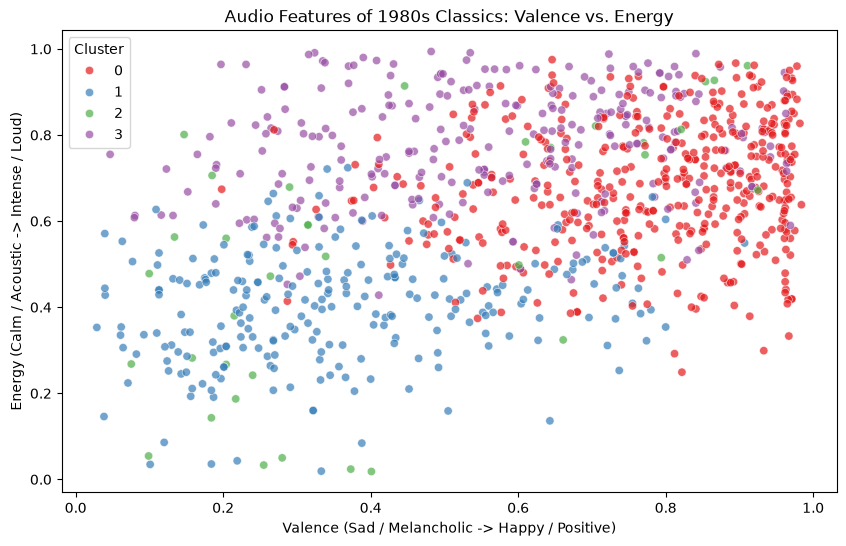

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
df = pd.read_csv("Datasets/1980sClassics.csv")

# 2. Select numerical audio features relevant for clustering
features = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 
            'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo']
X = df[features]

# 3. Standardize the features so large values (like Tempo) don't overpower small ones
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Initialize and fit the KMeans model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Convert cluster labels to a category so Seaborn handles the colors correctly
df['Cluster'] = df['Cluster'].astype("category")

# 5. Visualize the clusters using a scatter plot
# We plot Valence (Mood) against Energy (Intensity) as they best represent musical feel
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Valence', 
    y='Energy', 
    hue='Cluster', 
    palette='Set1', # Choose a distinct color palette
    alpha=0.7       # Make points slightly transparent to see overlapping tracks
)

# 6. Add labels and title for clarity
plt.title('Audio Features of 1980s Classics: Valence vs. Energy')
plt.xlabel('Valence (Sad / Melancholic -> Happy / Positive)')
plt.ylabel('Energy (Calm / Acoustic -> Intense / Loud)')

cluster_profiles = df.groupby('Cluster')[features].mean()
print(cluster_profiles)

# 7. Display the graph
plt.show()

***Results of the cluster analysis***

When the algoritm runs, the 998 different songs are grouped into 4 different
musical profiles. By looking at the average for each group, we can interpret
what each group/cluster represents in reality.

* The first cluster, cluster 0 [RED] - Pop songs (445 songs)

This is the biggest cluster and the songs are characterized by high "*danceability*"
(0.73) and high "*Valence*" (0.78). This means that the music is typical of the 80's
when everything was cheap, everyone was happy and in some cases, sniffing some funny stuff.

* Second cluster, cluster 1 [BLUE] - Acoustic ballads (249 songs)

These songs are noticeably slower with a lower energy (0.40). They have the highest
"*Acousticness*" (0.50) out of all groups and a low "*Valence*" (0.36). This indicates
a more melancholy and calm vibe.

* The third cluster, cluster 2 [GREEN] - Instrumental & Synth (36 songs)

These cluster have a high "*Instrumentalness*" (0.78) and usually don't contain
any or alot of vocals. Syntwave music recently made a small comback funnily enough.
Sounds great and it's relaxing.

* The fourth and final cluster, cluster 3 [Purple] - High energy rock and live music (268 songs)

This cluster has the highest "*Energy*" (0.77), the highest tempo with an average
BPM of 132 and the highest volume or "*Loudness*". It also contains the highest "*liveness*"
which indicate alot of live rock or punk rock which wasn't uncommon in the 80's.

***Quick explination of the plot***

The x-axis shows "*Valence*", which is a measurement of positivity vs sadness.
A 0 = sadder songs and a 1 = happier songs. 

The y-axis shows the "*Energy*" which measures if a song is intensive or relaxing.
A 0 = calmer songs and a 1 = more intense, amped songs